# RGB Binary LWE Secret Recovery - Self-contained Notebook

This notebook contains the full implementation in one place:

- binary LWE data generation
- RGB 3-channel feature encoding
- ViT-style column-token model
- binary support objective
- direct top-h decoding
- residual-based reranking
- streaming logs, history CSV, and plots

The default `smoke` profile is intentionally small. For the real run, set `PROFILE = "binary_h3_noiseless"` or `PROFILE = "binary_h3_noise1"` in the config cell.


In [13]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

CACHE_DIR = PROJECT_ROOT / "notebooks" / ".cache"
(CACHE_DIR / "matplotlib").mkdir(parents=True, exist_ok=True)
(CACHE_DIR / "ipython").mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(CACHE_DIR / "matplotlib"))
os.environ.setdefault("IPYTHONDIR", str(CACHE_DIR / "ipython"))

RUN_ROOT = PROJECT_ROOT / "notebooks" / "runs"
RUN_ROOT.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT={PROJECT_ROOT}")
print(f"RUN_ROOT={RUN_ROOT}")


PROJECT_ROOT=/home/yu_mcc/vit_PQC
RUN_ROOT=/home/yu_mcc/vit_PQC/notebooks/runs


In [14]:
import itertools
import json
import math
import random
import time
from dataclasses import asdict, dataclass

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))


cuda available: True
gpu: NVIDIA GeForce RTX 5070 Ti


## Config

`binary_h3_noiseless` matches the main RGB binary baseline. `binary_h3_noise1` adds rounded Gaussian error with `sigma_e=1.0`.


In [15]:
@dataclass
class ExperimentConfig:
    name: str = "smoke"
    seed: int = 20260428
    n: int = 16
    M: int = 512
    q: int = 127
    mode: str = "fixed_h"  # fixed_h or bernoulli
    h: int = 3
    p: float = 0.25
    sigma_e: float = 0.0
    batch_size: int = 64
    eval_batch_size: int = 128
    epochs: int = 2
    steps_per_epoch: int = 10
    eval_batches: int = 4
    lr: float = 1e-4
    weight_decay: float = 0.05
    embed_dim: int = 128
    num_heads: int = 8
    depth: int = 2
    dropout: float = 0.1
    log_every_steps: int = 5
    residual_topK: int = 10
    residual_eval_samples: int = 16


PROFILES = {
    "smoke": ExperimentConfig(name="smoke"),
    "binary_h3_noiseless": ExperimentConfig(
        name="binary_h3_noiseless",
        mode="fixed_h",
        h=3,
        sigma_e=0.0,
        batch_size=256,
        eval_batch_size=256,
        epochs=80,
        steps_per_epoch=500,
        eval_batches=8,
        embed_dim=512,
        depth=6,
        lr=1e-4,
        log_every_steps=25,
        residual_eval_samples=32,
    ),
    "binary_h3_noise1": ExperimentConfig(
        name="binary_h3_noise1",
        mode="fixed_h",
        h=3,
        sigma_e=1.0,
        batch_size=256,
        eval_batch_size=256,
        epochs=100,
        steps_per_epoch=600,
        eval_batches=8,
        embed_dim=512,
        depth=6,
        lr=1e-4,
        log_every_steps=25,
        residual_eval_samples=32,
    ),
    "binary_bernoulli_noise1": ExperimentConfig(
        name="binary_bernoulli_noise1",
        mode="bernoulli",
        p=0.25,
        sigma_e=1.0,
        batch_size=256,
        eval_batch_size=256,
        epochs=100,
        steps_per_epoch=600,
        eval_batches=8,
        embed_dim=512,
        depth=6,
        lr=1e-4,
        log_every_steps=25,
        residual_eval_samples=32,
    ),
}

PROFILE = os.environ.get("RGB_BINARY_PROFILE", "binary_h3_noise1")
# PROFILE = "binary_h3_noiseless"
# PROFILE = "binary_h3_noise1"

cfg = ExperimentConfig(**asdict(PROFILES[PROFILE]))
cfg.name = f"notebook_{cfg.name}"

OVERRIDES = {
    "epochs": None,
    "steps_per_epoch": None,
    "batch_size": None,
    "eval_batch_size": None,
    "eval_batches": None,
    "sigma_e": None,
    "residual_topK": None,
    "residual_eval_samples": None,
    "log_every_steps": None,
}
for key, value in OVERRIDES.items():
    if value is not None:
        setattr(cfg, key, value)

print("profiles:", sorted(PROFILES))
print(cfg)
print(f"streamed_train_samples={cfg.epochs * cfg.steps_per_epoch * cfg.batch_size:,}")


profiles: ['binary_bernoulli_noise1', 'binary_h3_noise1', 'binary_h3_noiseless', 'smoke']
ExperimentConfig(name='notebook_binary_h3_noise1', seed=20260428, n=16, M=512, q=127, mode='fixed_h', h=3, p=0.25, sigma_e=1.0, batch_size=256, eval_batch_size=256, epochs=100, steps_per_epoch=600, eval_batches=8, lr=0.0001, weight_decay=0.05, embed_dim=512, num_heads=8, depth=6, dropout=0.1, log_every_steps=25, residual_topK=10, residual_eval_samples=32)
streamed_train_samples=15,360,000


## Data and RGB Encoding

The input tensor has shape `[batch, 3, M, n + 1]`. The last column token is `b`; the first `n` column tokens are the columns of `A`.


In [16]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def generate_binary_s(cfg: ExperimentConfig, batch_size: int, device: torch.device) -> torch.Tensor:
    if cfg.mode == "fixed_h":
        s = torch.zeros(batch_size, cfg.n, dtype=torch.long, device=device)
        support = torch.rand(batch_size, cfg.n, device=device).topk(cfg.h, dim=1).indices
        s.scatter_(1, support, 1)
        return s
    if cfg.mode == "bernoulli":
        return (torch.rand(batch_size, cfg.n, device=device) < cfg.p).long()
    raise ValueError(f"unknown mode: {cfg.mode}")


def generate_lwe_batch(cfg: ExperimentConfig, batch_size: int, device: torch.device):
    s = generate_binary_s(cfg, batch_size, device)
    A = torch.randint(0, cfg.q, (batch_size, cfg.M, cfg.n), dtype=torch.long, device=device)
    if cfg.sigma_e > 0:
        e = torch.round(torch.randn(batch_size, cfg.M, device=device) * cfg.sigma_e).long()
    else:
        e = torch.zeros(batch_size, cfg.M, dtype=torch.long, device=device)
    prod = torch.bmm(A.float(), s.float().unsqueeze(-1)).squeeze(-1).round().long()
    b = torch.remainder(prod + e, cfg.q).unsqueeze(-1)
    return A, b, s, e.unsqueeze(-1)


def encode_rgb_3ch(A: torch.Tensor, b: torch.Tensor, q: int) -> torch.Tensor:
    matrix = torch.cat([A.float(), b.float()], dim=2)
    ch1 = matrix / q
    ch2 = torch.abs(matrix - q / 2) / (q / 2)
    ch3 = (torch.sin(2 * math.pi * matrix / q) + 1) / 2
    return torch.stack([ch1, ch2, ch3], dim=1).contiguous()


## Model

`Conv2d(3, embed_dim, kernel_size=(M, 1))` consumes all 3 RGB channels and all `M` equations for each column token. The transformer then mixes the `n + 1` column tokens.


In [17]:
class RGBBinaryViT(nn.Module):
    def __init__(self, M: int, n: int, embed_dim: int, num_heads: int, depth: int, dropout: float):
        super().__init__()
        self.M = M
        self.n = n
        self.patch_embed = nn.Conv2d(3, embed_dim, kernel_size=(M, 1))
        self.pos_embed = nn.Parameter(torch.randn(1, n + 1, embed_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.norm = nn.LayerNorm(embed_dim)
        self.transformer = nn.TransformerEncoder(layer, num_layers=depth)
        self.support_head = nn.Linear(embed_dim, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.size(1) != 3:
            raise ValueError(f"expected RGB 3-channel input, got {x.size(1)} channels")
        z = self.patch_embed(x).squeeze(2).transpose(1, 2)
        if z.size(1) != self.n + 1:
            raise ValueError(f"expected {self.n + 1} column tokens, got {z.size(1)}")
        z = self.norm(z + self.pos_embed)
        z = self.transformer(z)
        return self.support_head(z[:, : self.n]).squeeze(-1)


## Decoding, Metrics, and Residual Reranking

Direct decoding uses top-`h` for fixed-HW secrets. Residual reranking enumerates binary candidates inside the model's top-K coordinates and selects the one with the smallest centered LWE residual.


In [18]:
def centered_int(x: torch.Tensor, q: int) -> torch.Tensor:
    half = q // 2
    return torch.remainder(x + half, q) - half


def residual_score(A: torch.Tensor, b: torch.Tensor, s_hat: torch.Tensor, q: int) -> torch.Tensor:
    pred = torch.bmm(A.float(), s_hat.float().unsqueeze(-1)).squeeze(-1).round().long()
    r = centered_int(b.squeeze(-1) - torch.remainder(pred, q), q)
    return (r.float() ** 2).mean(dim=1)


def decode_logits(logits: torch.Tensor, cfg: ExperimentConfig) -> torch.Tensor:
    if cfg.mode == "fixed_h":
        idx = torch.topk(logits, k=cfg.h, dim=1).indices
        pred = torch.zeros_like(logits, dtype=torch.long)
        pred.scatter_(1, idx, 1)
        return pred
    return (torch.sigmoid(logits) > 0.5).long()


def compute_metrics(pred_s: torch.Tensor, true_s: torch.Tensor, A: torch.Tensor, b: torch.Tensor, cfg: ExperimentConfig):
    eps = 1e-8
    pred_support = pred_s.bool()
    true_support = true_s.bool()
    tp = (pred_support & true_support).float().sum()
    fp = (pred_support & ~true_support).float().sum()
    fn = (~pred_support & true_support).float().sum()
    return {
        "coord_acc": (pred_s == true_s).float().mean().item(),
        "support_precision": (tp / (tp + fp + eps)).item(),
        "support_recall": (tp / (tp + fn + eps)).item(),
        "full_match": (pred_s == true_s).all(dim=1).float().mean().item(),
        "mean_hw_pred": pred_s.float().sum(dim=1).mean().item(),
        "mean_hw_true": true_s.float().sum(dim=1).mean().item(),
        "residual_score": residual_score(A, b, pred_s, cfg.q).mean().item(),
    }


def enumerate_binary_candidates(indices, n: int, fixed_h=None, device=None) -> torch.Tensor:
    indices = [int(i) for i in indices]
    if fixed_h is None:
        subsets = []
        for r in range(len(indices) + 1):
            subsets.extend(itertools.combinations(indices, r))
    else:
        subsets = list(itertools.combinations(indices, fixed_h))
    candidates = torch.zeros(len(subsets), n, dtype=torch.long, device=device)
    for row, subset in enumerate(subsets):
        if subset:
            candidates[row, list(subset)] = 1
    return candidates


@torch.no_grad()
def residual_rerank_one(A_one, b_one, logits_one, cfg: ExperimentConfig):
    topK = min(cfg.residual_topK, cfg.n)
    idx = torch.topk(logits_one, k=topK).indices.detach().cpu().tolist()
    fixed_h = cfg.h if cfg.mode == "fixed_h" else None
    candidates = enumerate_binary_candidates(idx, cfg.n, fixed_h=fixed_h, device=logits_one.device)
    scores = []
    for cand in candidates.split(4096):
        scores.append(
            residual_score(
                A_one.unsqueeze(0).expand(cand.size(0), -1, -1),
                b_one.unsqueeze(0).expand(cand.size(0), -1, -1),
                cand,
                cfg.q,
            )
        )
    scores = torch.cat(scores, dim=0)
    return candidates[torch.argmin(scores)]


## Evaluation and Training Loop

The loop streams step-level logs in real time and saves `config.json`, `train.log`, and `history.csv` under `notebooks/runs/`.


In [19]:
@torch.no_grad()
def evaluate_model(model: nn.Module, cfg: ExperimentConfig, device: torch.device):
    model.eval()
    rows = []
    rerank_rows = []
    for batch_idx in range(cfg.eval_batches):
        A, b, s, _ = generate_lwe_batch(cfg, cfg.eval_batch_size, device)
        logits = model(encode_rgb_3ch(A, b, cfg.q))
        pred = decode_logits(logits, cfg)
        rows.append(compute_metrics(pred, s, A, b, cfg))

        if batch_idx == 0 and cfg.residual_eval_samples > 0:
            limit = min(cfg.residual_eval_samples, A.size(0))
            rr = [residual_rerank_one(A[i], b[i], logits[i], cfg) for i in range(limit)]
            rr = torch.stack(rr, dim=0)
            rerank_rows.append(compute_metrics(rr, s[:limit], A[:limit], b[:limit], cfg))

    out = pd.DataFrame(rows).mean().to_dict()
    if rerank_rows:
        rr = pd.DataFrame(rerank_rows).mean().to_dict()
        out.update({f"rerank_{k}": v for k, v in rr.items()})
    return out


def make_loss(cfg: ExperimentConfig, device: torch.device):
    if cfg.mode == "fixed_h":
        pos_weight = torch.tensor([(cfg.n - cfg.h) / cfg.h], device=device)
    else:
        pos_weight = torch.tensor([(1 - cfg.p) / cfg.p], device=device)
    return nn.BCEWithLogitsLoss(pos_weight=pos_weight)


def train_model(cfg: ExperimentConfig):
    set_seed(cfg.seed)
    torch.set_float32_matmul_precision("high")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = RGBBinaryViT(cfg.M, cfg.n, cfg.embed_dim, cfg.num_heads, cfg.depth, cfg.dropout).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    criterion = make_loss(cfg, device)

    run_dir = RUN_ROOT / f"{cfg.name}_{time.strftime('%Y%m%d_%H%M%S')}"
    run_dir.mkdir(parents=True, exist_ok=True)
    log_path = run_dir / "train.log"
    hist_path = run_dir / "history.csv"
    (run_dir / "config.json").write_text(json.dumps(asdict(cfg), indent=2), encoding="utf-8")

    def log(msg: str):
        print(msg, flush=True)
        with log_path.open("a", encoding="utf-8") as f:
            f.write(msg + "\n")

    log(f"run_dir={run_dir}")
    log(f"device={device}")
    log(f"config={cfg}")
    log(f"streamed_train_samples={cfg.epochs * cfg.steps_per_epoch * cfg.batch_size:,}")
    log(f"model_params={sum(p.numel() for p in model.parameters()):,}")
    log(f"patch_embed_weight_shape={tuple(model.patch_embed.weight.shape)}")

    history = []
    t0 = time.time()
    for epoch in range(1, cfg.epochs + 1):
        model.train()
        losses, coord_accs, full_matches = [], [], []
        e0 = time.time()
        for step in range(1, cfg.steps_per_epoch + 1):
            A, b, s, _ = generate_lwe_batch(cfg, cfg.batch_size, device)
            logits = model(encode_rgb_3ch(A, b, cfg.q))
            loss = criterion(logits, s.float())
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            with torch.no_grad():
                pred = decode_logits(logits, cfg)
                losses.append(loss.item())
                coord_accs.append((pred == s).float().mean().item())
                full_matches.append((pred == s).all(dim=1).float().mean().item())

            if step % cfg.log_every_steps == 0 or step == cfg.steps_per_epoch:
                recent = min(cfg.log_every_steps, len(losses))
                log(
                    f"epoch {epoch:03d} step {step:05d}/{cfg.steps_per_epoch} | "
                    f"loss={np.mean(losses[-recent:]):.4f} | "
                    f"coord={np.mean(coord_accs[-recent:]):.3f} | "
                    f"full={np.mean(full_matches[-recent:]):.3f} | "
                    f"elapsed_epoch={time.time() - e0:.1f}s"
                )

        val = evaluate_model(model, cfg, device)
        row = {
            "epoch": epoch,
            "train_loss": float(np.mean(losses)),
            "train_coord_acc": float(np.mean(coord_accs)),
            "train_full_match": float(np.mean(full_matches)),
            **{f"val_{k}": v for k, v in val.items()},
        }
        history.append(row)
        pd.DataFrame(history).to_csv(hist_path, index=False)
        log(
            f"epoch {epoch:03d} done | loss={row['train_loss']:.4f} | "
            f"train_full={row['train_full_match']:.3f} | "
            f"val_full={row['val_full_match']:.3f} | "
            f"val_coord={row['val_coord_acc']:.3f} | "
            f"val_recall={row['val_support_recall']:.3f} | "
            f"rerank_full={row.get('val_rerank_full_match', float('nan')):.3f} | "
            f"residual={row['val_residual_score']:.2f} | "
            f"elapsed={time.time() - t0:.1f}s"
        )
        if row["val_full_match"] >= 0.995 or row.get("val_rerank_full_match", 0.0) >= 0.995:
            log("early_stop=full_match_threshold")
            break

    log(f"final_history={hist_path}")
    return model, run_dir


## Raw Data Check

This cell displays the binary secret and a small raw slice of `A`, `b`, and `e`.


In [20]:
set_seed(cfg.seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
A, b, s, e = generate_lwe_batch(cfg, batch_size=4, device=device)
X = encode_rgb_3ch(A, b, cfg.q)

assert X.shape == (4, 3, cfg.M, cfg.n + 1)
assert X.size(1) == 3

print(f"device={device}")
print(f"A shape={tuple(A.shape)}, b shape={tuple(b.shape)}, s shape={tuple(s.shape)}, X shape={tuple(X.shape)}")
print(f"channel min={X.amin(dim=(0,2,3)).detach().cpu().numpy()}")
print(f"channel max={X.amax(dim=(0,2,3)).detach().cpu().numpy()}")

display(pd.DataFrame(s.detach().cpu().numpy(), columns=[f"s{j}" for j in range(cfg.n)]))
display(pd.DataFrame(A[0, : min(12, cfg.M)].detach().cpu().numpy(), columns=[f"a{j}" for j in range(cfg.n)]))
display(pd.DataFrame({
    "b": b[0, : min(12, cfg.M), 0].detach().cpu().numpy(),
    "e": e[0, : min(12, cfg.M), 0].detach().cpu().numpy(),
}))


device=cuda
A shape=(4, 512, 16), b shape=(4, 512, 1), s shape=(4, 16), X shape=(4, 3, 512, 17)
channel min=[0.000000e+00 7.874016e-03 3.823638e-05]
channel max=[0.992126   1.         0.99996173]


,s0,s1,s2,s3,s4,s5,s6,s7,s8,s9,s10,s11,s12,s13,s14,s15
0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1
1,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0
2,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0
3,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0


,a0,a1,a2,a3,a4,a5,a6,a7,a8,a9,a10,a11,a12,a13,a14,a15
0,115,80,97,83,9,85,93,89,5,90,72,75,70,105,84,105
1,61,29,33,21,17,91,44,9,66,111,65,29,47,73,45,92
2,97,52,8,46,114,54,20,65,53,114,5,43,94,55,124,16
3,85,9,9,54,33,92,81,118,41,26,21,125,51,24,93,109
4,14,106,26,76,18,63,25,70,29,97,50,37,38,32,40,98
5,108,50,49,13,6,28,125,91,21,126,19,45,21,74,61,16
6,100,34,79,60,103,21,47,17,117,69,113,39,16,116,70,56
7,103,85,63,5,69,82,124,14,113,111,64,78,27,120,122,121
8,5,74,52,91,75,48,93,65,15,126,21,62,12,120,108,71
9,110,125,4,54,38,7,51,53,63,102,30,43,76,109,23,106


,b,e
0,13,-2
1,2,-1
2,123,-1
3,97,-1
4,77,-1
5,26,1
6,113,1
7,86,0
8,71,0
9,75,0


## Model Sanity Check

This confirms the model consumes all 3 channels and emits one binary support logit per secret coordinate.


In [21]:
model = RGBBinaryViT(cfg.M, cfg.n, cfg.embed_dim, cfg.num_heads, cfg.depth, cfg.dropout).to(device)
print(model.patch_embed)
print(f"patch weight shape={tuple(model.patch_embed.weight.shape)}")
assert model.patch_embed.weight.shape[1] == 3

with torch.no_grad():
    logits = model(X)
    pred = decode_logits(logits, cfg)

assert logits.shape == (4, cfg.n)
assert pred.shape == s.shape

metrics = compute_metrics(pred, s, A, b, cfg)
true_residual = residual_score(A, b, s, cfg.q).mean().item()
print(f"logits shape={tuple(logits.shape)}")
print(f"true residual score={true_residual:.4f}")
print(metrics)

display(pd.DataFrame({
    "coord": list(range(cfg.n)),
    "true_s": s[0].detach().cpu().numpy(),
    "pred_s_before_train": pred[0].detach().cpu().numpy(),
    "logit_before_train": logits[0].detach().cpu().numpy(),
}))


Conv2d(3, 512, kernel_size=(512, 1), stride=(1, 1))
patch weight shape=(512, 3, 512, 1)
logits shape=(4, 16)
true residual score=1.1309
{'coord_acc': 0.78125, 'support_precision': 0.4166666567325592, 'support_recall': 0.4166666567325592, 'full_match': 0.0, 'mean_hw_pred': 3.0, 'mean_hw_true': 3.0, 'residual_score': 1349.595703125}


/home/yu_mcc/miniconda3/envs/lattice_env/lib/python3.10/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


,coord,true_s,pred_s_before_train,logit_before_train
0,0,0,1,0.680466
1,1,0,0,0.166678
2,2,0,0,-0.132597
3,3,0,0,-0.227646
4,4,0,0,0.053286
5,5,0,0,0.185136
6,6,0,0,-0.619725
7,7,1,0,0.341451
8,8,0,0,-0.418747
9,9,0,0,0.044309


## Train

Set `RUN_TRAIN = False` if you only want to inspect definitions and sanity checks.


In [22]:
RUN_TRAIN = True

if RUN_TRAIN:
    trained_model, run_dir = train_model(cfg)
else:
    trained_model, run_dir = None, None

print(f"run_dir={run_dir}")


run_dir=/home/yu_mcc/vit_PQC/notebooks/runs/notebook_binary_h3_noise1_20260428_014214
device=cuda
config=ExperimentConfig(name='notebook_binary_h3_noise1', seed=20260428, n=16, M=512, q=127, mode='fixed_h', h=3, p=0.25, sigma_e=1.0, batch_size=256, eval_batch_size=256, epochs=100, steps_per_epoch=600, eval_batches=8, lr=0.0001, weight_decay=0.05, embed_dim=512, num_heads=8, depth=6, dropout=0.1, log_every_steps=25, residual_topK=10, residual_eval_samples=32)
streamed_train_samples=15,360,000
model_params=19,711,489
patch_embed_weight_shape=(512, 3, 512, 1)


/home/yu_mcc/miniconda3/envs/lattice_env/lib/python3.10/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


epoch 001 step 00025/600 | loss=2.4227 | coord=0.696 | full=0.002 | elapsed_epoch=0.8s
epoch 001 step 00050/600 | loss=1.2854 | coord=0.696 | full=0.002 | elapsed_epoch=1.5s
epoch 001 step 00075/600 | loss=1.2204 | coord=0.695 | full=0.002 | elapsed_epoch=2.1s
epoch 001 step 00100/600 | loss=1.1495 | coord=0.693 | full=0.001 | elapsed_epoch=2.8s
epoch 001 step 00125/600 | loss=1.1343 | coord=0.696 | full=0.001 | elapsed_epoch=3.4s
epoch 001 step 00150/600 | loss=1.1339 | coord=0.695 | full=0.002 | elapsed_epoch=4.0s
epoch 001 step 00175/600 | loss=1.1328 | coord=0.696 | full=0.001 | elapsed_epoch=4.7s
epoch 001 step 00200/600 | loss=1.1314 | coord=0.697 | full=0.001 | elapsed_epoch=5.4s
epoch 001 step 00225/600 | loss=1.1319 | coord=0.695 | full=0.001 | elapsed_epoch=6.0s
epoch 001 step 00250/600 | loss=1.1313 | coord=0.696 | full=0.002 | elapsed_epoch=6.7s
epoch 001 step 00275/600 | loss=1.1308 | coord=0.695 | full=0.001 | elapsed_epoch=7.4s
epoch 001 step 00300/600 | loss=1.1306 | co

## History and Plots

The plots use plain lines without point markers so long runs stay readable.


history=/home/yu_mcc/vit_PQC/notebooks/runs/notebook_binary_h3_noise1_20260428_014214/history.csv


,epoch,train_loss,train_coord_acc,train_full_match,val_coord_acc,val_support_precision,val_support_recall,val_full_match,val_mean_hw_pred,val_mean_hw_true,val_residual_score,val_rerank_coord_acc,val_rerank_support_precision,val_rerank_support_recall,val_rerank_full_match,val_rerank_mean_hw_pred,val_rerank_mean_hw_true,val_rerank_residual_score
95,96,1.126425,0.694967,0.001771,0.699829,0.199544,0.199544,0.001953,3.0,3.0,1340.764496,0.738281,0.302083,0.302083,0.15625,3.0,3.0,1021.088379
96,97,1.126431,0.695527,0.001758,0.696106,0.189616,0.189616,0.001465,3.0,3.0,1343.162506,0.753906,0.343750,0.343750,0.21875,3.0,3.0,941.020752
97,98,1.126418,0.695454,0.001921,0.695251,0.187337,0.187337,0.002930,3.0,3.0,1341.456757,0.742188,0.312500,0.312500,0.15625,3.0,3.0,1023.549133
98,99,1.126422,0.695377,0.001940,0.692810,0.180827,0.180827,0.002441,3.0,3.0,1341.477249,0.726562,0.270833,0.270833,0.09375,3.0,3.0,1098.834351
99,100,1.126423,0.695453,0.001855,0.692688,0.180501,0.180501,0.000977,3.0,3.0,1342.369202,0.769531,0.385417,0.385417,0.28125,3.0,3.0,868.601746


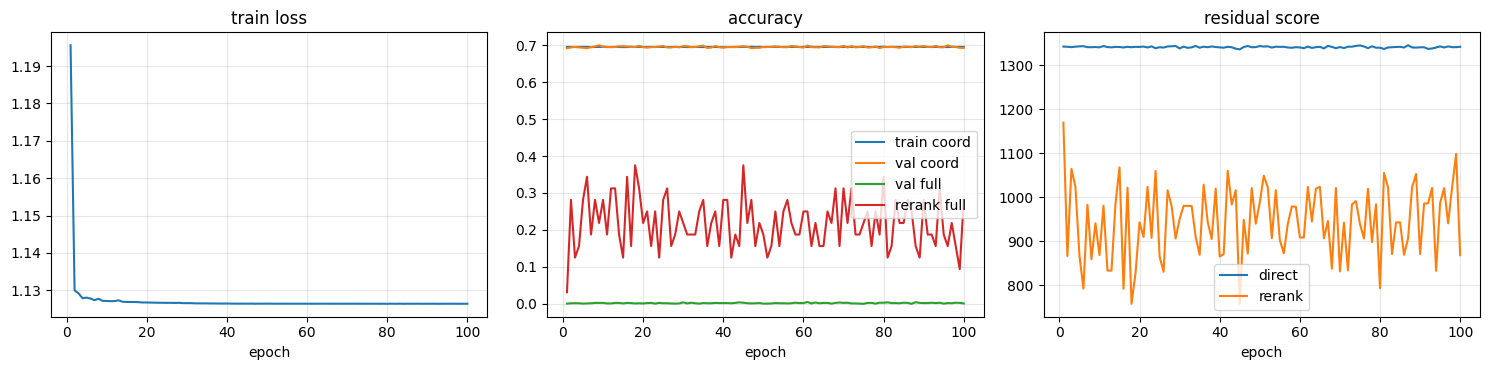

In [23]:
if run_dir is None:
    candidates = sorted(RUN_ROOT.glob(f"{cfg.name}_*/history.csv"), key=lambda p: p.stat().st_mtime)
    hist_path = candidates[-1] if candidates else None
else:
    hist_path = Path(run_dir) / "history.csv"

if hist_path is None or not hist_path.exists():
    raise FileNotFoundError("No history.csv found. Run training first or point hist_path to an existing run.")

hist = pd.read_csv(hist_path)
print(f"history={hist_path}")
display(hist.tail())

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
axes[0].plot(hist["epoch"], hist["train_loss"])
axes[0].set_title("train loss")
axes[0].set_xlabel("epoch")
axes[0].grid(True, alpha=0.3)

axes[1].plot(hist["epoch"], hist["train_coord_acc"], label="train coord")
axes[1].plot(hist["epoch"], hist["val_coord_acc"], label="val coord")
axes[1].plot(hist["epoch"], hist["val_full_match"], label="val full")
if "val_rerank_full_match" in hist.columns:
    axes[1].plot(hist["epoch"], hist["val_rerank_full_match"], label="rerank full")
axes[1].set_title("accuracy")
axes[1].set_xlabel("epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(hist["epoch"], hist["val_residual_score"], label="direct")
if "val_rerank_residual_score" in hist.columns:
    axes[2].plot(hist["epoch"], hist["val_rerank_residual_score"], label="rerank")
axes[2].set_title("residual score")
axes[2].set_xlabel("epoch")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Recent Log Lines

In [24]:
log_path = hist_path.parent / "train.log"
print(f"log={log_path}")
if log_path.exists():
    lines = log_path.read_text(encoding="utf-8").splitlines()
    print("\n".join(lines[-25:]))
else:
    print("train.log does not exist yet")


log=/home/yu_mcc/vit_PQC/notebooks/runs/notebook_binary_h3_noise1_20260428_014214/train.log
epoch 100 step 00050/600 | loss=1.1264 | coord=0.696 | full=0.001 | elapsed_epoch=1.3s
epoch 100 step 00075/600 | loss=1.1264 | coord=0.697 | full=0.002 | elapsed_epoch=1.9s
epoch 100 step 00100/600 | loss=1.1264 | coord=0.695 | full=0.001 | elapsed_epoch=2.6s
epoch 100 step 00125/600 | loss=1.1264 | coord=0.696 | full=0.002 | elapsed_epoch=3.2s
epoch 100 step 00150/600 | loss=1.1264 | coord=0.696 | full=0.002 | elapsed_epoch=3.9s
epoch 100 step 00175/600 | loss=1.1265 | coord=0.696 | full=0.003 | elapsed_epoch=4.6s
epoch 100 step 00200/600 | loss=1.1265 | coord=0.694 | full=0.002 | elapsed_epoch=5.2s
epoch 100 step 00225/600 | loss=1.1264 | coord=0.697 | full=0.002 | elapsed_epoch=5.9s
epoch 100 step 00250/600 | loss=1.1264 | coord=0.694 | full=0.002 | elapsed_epoch=6.5s
epoch 100 step 00275/600 | loss=1.1264 | coord=0.695 | full=0.002 | elapsed_epoch=7.2s
epoch 100 step 00300/600 | loss=1.1265